PhonePe digital payments analysis

Analyzing transactions and demographic data

Importing the necessary libraries.

In [352]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

Importing the datasets.

In [3]:
# Define file paths and load data.
from pathlib import Path
# Define the data directory
DATA_DIR = Path.cwd() / 'data'
# Define filepaths
a=r"C:\Users\USER\Desktop\state_txn_users.csv"
b=r"C:\Users\USER\Desktop\state_txnsplit.csv"
c=r"C:\Users\USER\Desktop\state_devicedata.csv"
d=r"C:\Users\USER\Desktop\dist_txn_users.csv"
e=r"C:\Users\USER\Desktop\dist_demo.csv"

In [4]:
s_txn_users=pd.read_csv(a)
s_txnsplit=pd.read_csv(b)
s_devicedata=pd.read_csv(c)
d_txn_users=pd.read_csv(d)
d_demo=pd.read_csv(e)

In [28]:
#####################

Task 1: Data Cleaning

Identifying null values in the dataset and replaced them with appropriate substitutes based on context.This ensures data completeness and consistency, allowing for more accurate analysis and reliable insights.

In [6]:
# checking for numm values,
s_txn_users.isna().sum()

State               0
Year                0
Quarter             0
Transactions        0
Amount (INR)        1
ATV (INR)           0
Registered Users    0
App Opens           0
dtype: int64

All datasets were verified to contain zero missing values, ensuring completeness for analysis.The only exception is the demographic dataset (d_demo), which has some missing entries.However, these fields are not relevant to the subsequent analytical tasks, so they do not impact the overall results or insights.

In [8]:
# There is only one missing value in the state_txn_users in the "Amount (INR)" column,so replacing it from below steps.
x=s_txn_users["Amount (INR)"]

In [10]:
x=x.astype(str).str.replace(",","")

In [12]:
# converting str to numeric datatype using pd.to_numeric(errors="coerce")
x=pd.to_numeric(x,errors="coerce")

In [15]:
# filling the null values using interpolation method as below,
x=x.interpolate(method="linear")

In [16]:
x=x.astype("int64")

In [22]:
s_txn_users["Amount (INR)"]=x

In [31]:
# changing the required column datatypes to integer datatypes.
columns=["Transactions","ATV (INR)","Registered Users","App Opens"]

In [34]:
s_txn_users[columns]=s_txn_users[columns].apply(lambda x:x.astype(str).str.replace(",",""))

In [35]:
s_txn_users[columns] = s_txn_users[columns].apply(lambda x:pd.to_numeric(x,errors="coerce"))

In [39]:
s_txn_users.loc[26,"ATV (INR)"]=int(s_txn_users.loc[26,"Amount (INR)"]/s_txn_users.loc[26,"Transactions"])

In [52]:
##################################

Task 2: Evaluate the dataset to determine the total number of states represented and identified the state with the highest count of districts.

In [55]:
# using d_demo dataset.
# value_counts() function to count the frequency of each state,
# len() function to count the number of states.
print("The total number of states mentioned in the datasets are :"+str(len(d_demo["State"].value_counts())))

The total number of states mentioned in the datasets are :36


In [349]:

print("The state with the maximun number of districts is : "+d_demo["State"].value_counts().idxmax()+" with "+str(d_demo["State"].value_counts().max())+" districts.")

The state with the maximun number of districts is : Uttar Pradesh with 75 districts.


In [99]:
############################################

Task 3: Analyze transaction trends over the years for each state.

In [57]:
# using s_txn_users dataset.
s_txn_sum=s_txn_users.groupby("State").agg({"Transactions":"sum","Amount (INR)":"sum"})

In [58]:
s_txn_sum1=s_txn_sum.sort_values(by="Transactions",ascending=False)

In [351]:
# below table shows the total number od transactions and total transaction amount from each state over time,
s_txn_sum1

,Transactions,Amount (INR)
State,,
Karnataka,2981044533,4361395878907
Maharashtra,2833670154,4290995253331
Telangana,2347430243,4574245879739
Andhra Pradesh,1781091169,3940636991422
Rajasthan,1382918930,2625584351282
Uttar Pradesh,1314714390,2399757104087
Madhya Pradesh,1100253728,1915100967833
Delhi,1011031124,1649942211117
West Bengal,942286041,1452706824856


In [60]:
# Top 5 states by transactions,
s_txn_sum1.head()

,Transactions,Amount (INR)
State,,
Karnataka,2981044533,4361395878907
Maharashtra,2833670154,4290995253331
Telangana,2347430243,4574245879739
Andhra Pradesh,1781091169,3940636991422
Rajasthan,1382918930,2625584351282


In [62]:
s_txn_sum1.tail()

,Transactions,Amount (INR)
State,,
Meghalaya,5648913,12541621895
Mizoram,2162776,6317141435
Ladakh,1880109,6606978450
Andaman & Nicobar Islands,1223565,3641817860
Lakshadweep,71610,192158684


In [107]:
#######################################################

Task 4: Identify the most frequent transaction type in each state and quarter.

In [64]:
# Using s_txnsplit dataset
# checking for datatypes.
s_txnsplit.dtypes

State               object
Year                 int64
Quarter              int64
Transaction Type    object
Transactions        object
Amount (INR)        object
ATV (INR)           object
dtype: object

In [65]:
columns=["Transactions","Amount (INR)","ATV (INR)"]

In [66]:
# Converting object datatypes to numeric datatypes using lambda, pd.to_numeric() and string functions as below:
s_txnsplit[columns]=s_txnsplit[columns].apply(lambda x:x.astype(str).str.replace(",",""))

In [67]:
s_txnsplit[columns]=s_txnsplit[columns].apply(lambda x:pd.to_numeric(x,errors="coerce"))

In [98]:
# obtaining the indexes for maximun number of transactions for each state-year-quarter group,
idx=s_txnsplit.groupby(["State","Year","Quarter"])["Transactions"].idxmax()

In [99]:
res=s_txnsplit.loc[idx].reset_index()

In [109]:
res=res.drop(columns=["index"])

In [112]:
# saving the result in excel as below:
res.to_excel("freq_Ttype_per_state_Q.xlsx",index=False)

In [82]:
########################################################

Task 5: Determine the device brand with the highest no of registered users in each state.

In [116]:
# using s_deviedata dataset.
columns=["Registered Users","Percentage"]

In [117]:
# converting object to int datatype 
s_devicedata[columns]=s_devicedata[columns].apply(lambda x:x.astype(str).str.replace(",",""))

In [121]:
s_devicedata["Percentage"]=s_devicedata["Percentage"].astype(str).str.replace("%","")

In [122]:
s_devicedata[columns]=s_devicedata[columns].apply(lambda x:x.astype("int64"))

In [126]:
max_devices=s_devicedata.groupby(["State","Brand"])["Registered Users"].sum().reset_index()

In [128]:
idxmax=max_devices.groupby("State")["Registered Users"].idxmax()

In [129]:
result=max_devices.loc[idxmax]

In [131]:
result.to_excel("max_regUsers_device_brand.xlsx",index=False)

In [133]:
#################################################

Task 6: Create a list of top district per state based on population.

In [138]:
# Using d_demo dataset.
clms=["Population","Area (sq km)","Density"]

In [139]:
d_demo[clms]=d_demo[clms].apply(lambda x:x.astype(str).str.replace(",",""))
d_demo[clms]=d_demo[clms].apply(lambda x:pd.to_numeric(x,errors="coerce"))

In [143]:
# finding indexes of the districts with max population in every state
idx_max=d_demo.groupby("State")["Population"].idxmax()
res=d_demo.iloc[idx_max,[0,1,3]]

In [144]:
res=res.sort_values(by="Population",ascending=False)

In [146]:
# saving the result into excel
res.to_excel("most_populated_dist_per_state.xlsx",index=False)

In [148]:
import matplotlib.pyplot as plt

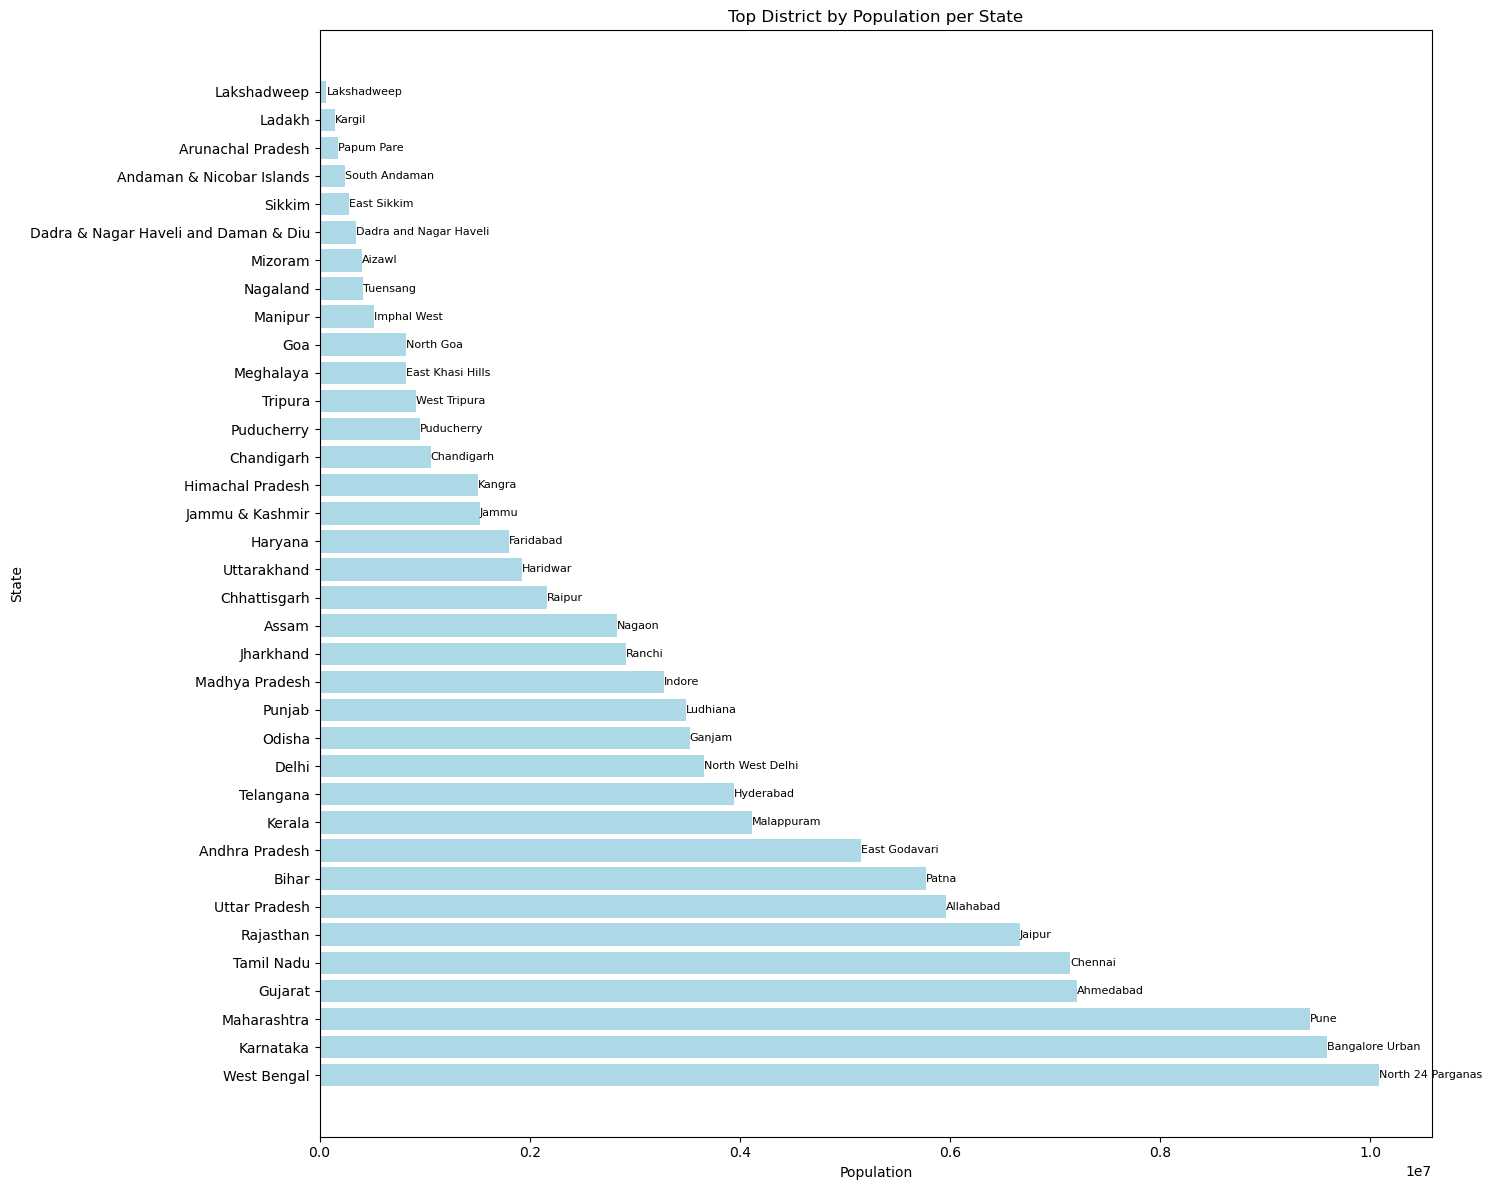

In [156]:
plt.figure(figsize=(15,12))
plt.barh(res["State"], res["Population"], color="lightblue")

for i, (pop, dist) in enumerate(zip(res["Population"],res["District"])):
    plt.text(pop,i,dist,va="center",fontsize=8)

plt.xlabel("Population")
plt.ylabel("State")
plt.title("Top District by Population per State")
plt.tight_layout()
plt.savefig("most_populated_dist_per_state.png",dpi=300,bbox_inches="tight")
plt.show()

In [157]:
##############################################

Task 7: calculate the average transaction (ATV) value for each state and identify top 5 and bottom 5 states by ATV.

In [159]:
# using s_txn_users dataset.
avg_ATV=s_txn_users.groupby("State").agg({"ATV (INR)":"mean"})

In [161]:
avg_ATV=avg_ATV.sort_values(by="ATV (INR)",ascending=False)

In [162]:
avg_ATV=avg_ATV.astype("int64").reset_index()

In [163]:
avg_ATV

,State,ATV (INR)
0,Ladakh,3408
1,Andaman & Nicobar Islands,3159
2,Mizoram,2927
3,Lakshadweep,2776
4,Arunachal Pradesh,2638
5,Manipur,2621
6,Nagaland,2609
7,Jammu & Kashmir,2508
8,Chandigarh,2113
9,Sikkim,2087


In [171]:
avg_ATV.to_excel("Avg_ATV_per_state.xlsx",index=False)

In [170]:
##################################################

Task 8: Analyze app usage trends,
calculate the total number of app opens over the years and quarters for each state.

In [179]:
# using s_txn_users dataset
x=s_txn_users.groupby("State")["App Opens"].sum().reset_index().sort_values(by="App Opens",ascending=False)

In [181]:
x.to_excel("total_appopens_per_state_overtime.xlsx",index=False)

Identifying trends in app usage by creating a lineplot showing the number of app opens over time for Telangana state.

In [183]:
state="Telangana"
df=s_txn_users[s_txn_users["State"]==state]

In [184]:
df1=df.groupby(["Year","Quarter"]).agg({"App Opens":"sum"}).reset_index()

In [185]:
df1["Y_Q"]=df1["Year"].astype(str)+"-Q"+df1["Quarter"].astype(str)

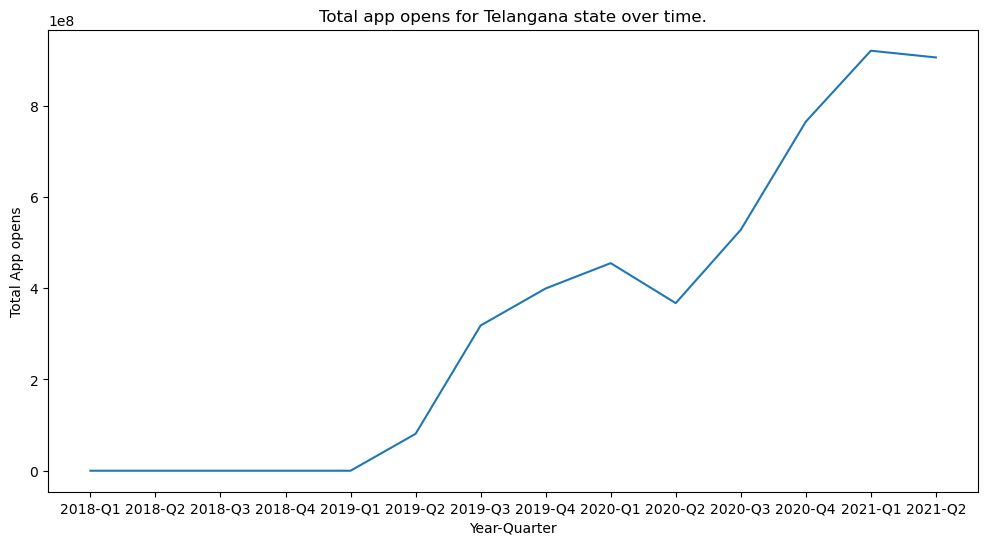

In [193]:
plt.figure(figsize=(12,6))
plt.plot(df1["Y_Q"],df1["App Opens"])
plt.xlabel("Year-Quarter")
plt.ylabel("Total App opens")
plt.title("Total app opens for Telangana state over time.")
plt.savefig("Appopens_TG.png",dpi=300,bbox_inches="tight")
plt.show()

From the above line graph, App opens declined in 2020 Q2 due to pandemic lockdowns, reflecting reduced digital engagement during that period. The trend reflects how external events can directly influence app usage patterns.

In [165]:
#######################################################

Task 9: Distribution of transaction types.

In [196]:
# Using s_txnsplit dataset.
df11=s_txnsplit[s_txnsplit["Year"]==s_txnsplit["Year"].max()]

In [197]:
df11=df11[df11["Quarter"]==df11["Quarter"].max()]

In [200]:
# top 10 states by transaction volumes
grouped=df11.groupby("State")["Transactions"].sum().reset_index().sort_values(by="Transactions",ascending=False).head(10)

In [206]:
states=grouped["State"].values

In [208]:
states_top10=df11[df11["State"].isin(states)]

In [212]:
states_top10.to_excel("distribution_Ttype_top10_states.xlsx",index=False)

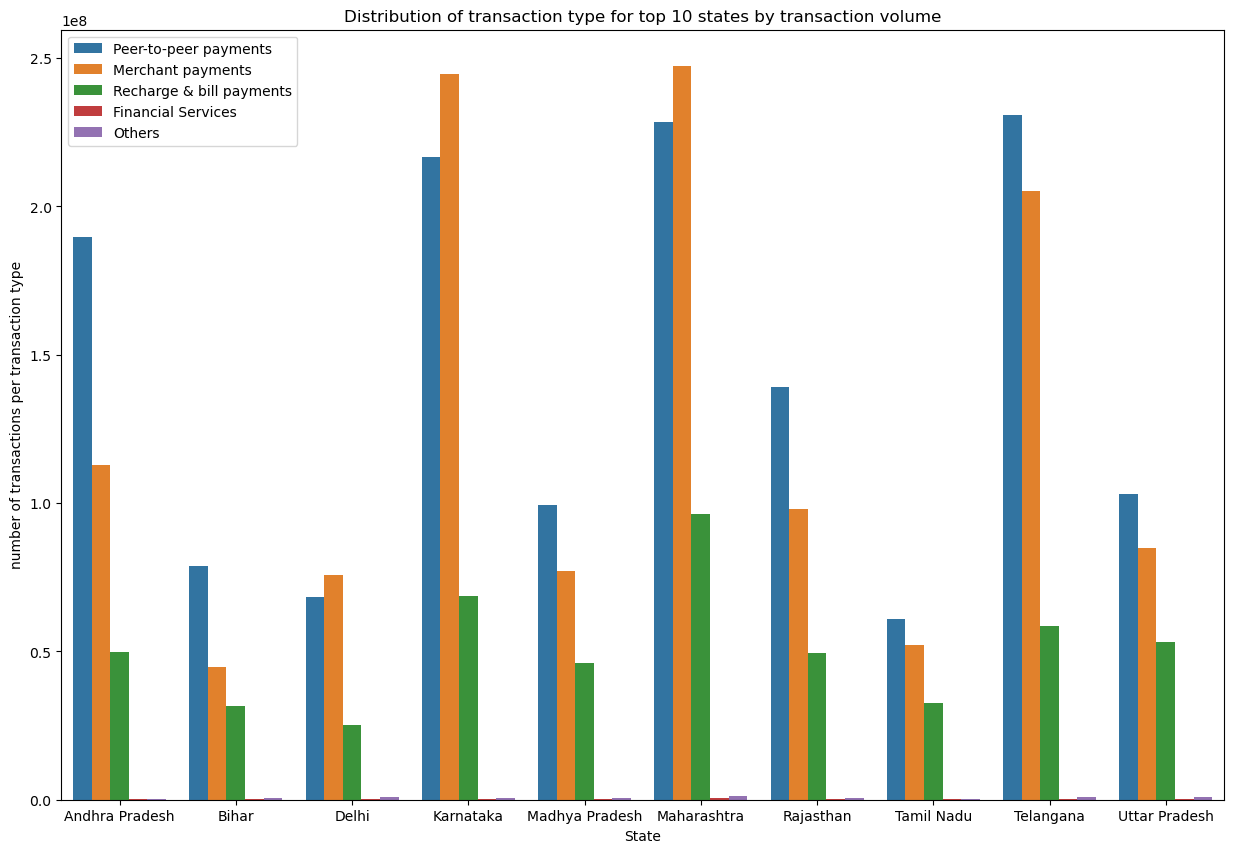

In [211]:
plt.figure(figsize=(15,10))
sns.barplot(data=states_top10,x="State",y="Transactions",hue="Transaction Type")
plt.xlabel("State")
plt.ylabel("number of transactions per transaction type")
plt.title("Distribution of transaction type for top 10 states by transaction volume")
plt.savefig("distribution_Ttype_top10_states.png",dpi=300,bbox_inches="tight")
plt.legend()
plt.show()

In [190]:
#################################################

Task 10: Date merging and advanced analysis.

merge the s_txn_users and d_demo to calculate the ratio of registered users to the population for each state.

In [237]:
# getting the latest data from s_txn_users that is year 2021 and quarter 2

recent=s_txn_users[(s_txn_users["Year"]==2021)&(s_txn_users["Quarter"]==2)].iloc[:,[0,6]]

In [239]:
d_latest=d_demo.groupby("State")["Population"].sum().reset_index()

In [240]:
d_latest["Population"]=d_latest["Population"].astype("int64")

In [242]:
merged_data=pd.merge(recent,d_latest,on="State")

In [244]:
merged_data["Ratio"]=merged_data["Registered Users"]*100/merged_data["Population"]

In [245]:
merged_data["Ratio"]=merged_data["Ratio"].astype("int64")

In [253]:
merged_data.to_excel("ratio_regUsers_to_pop_per_state.xlsx",index=False)

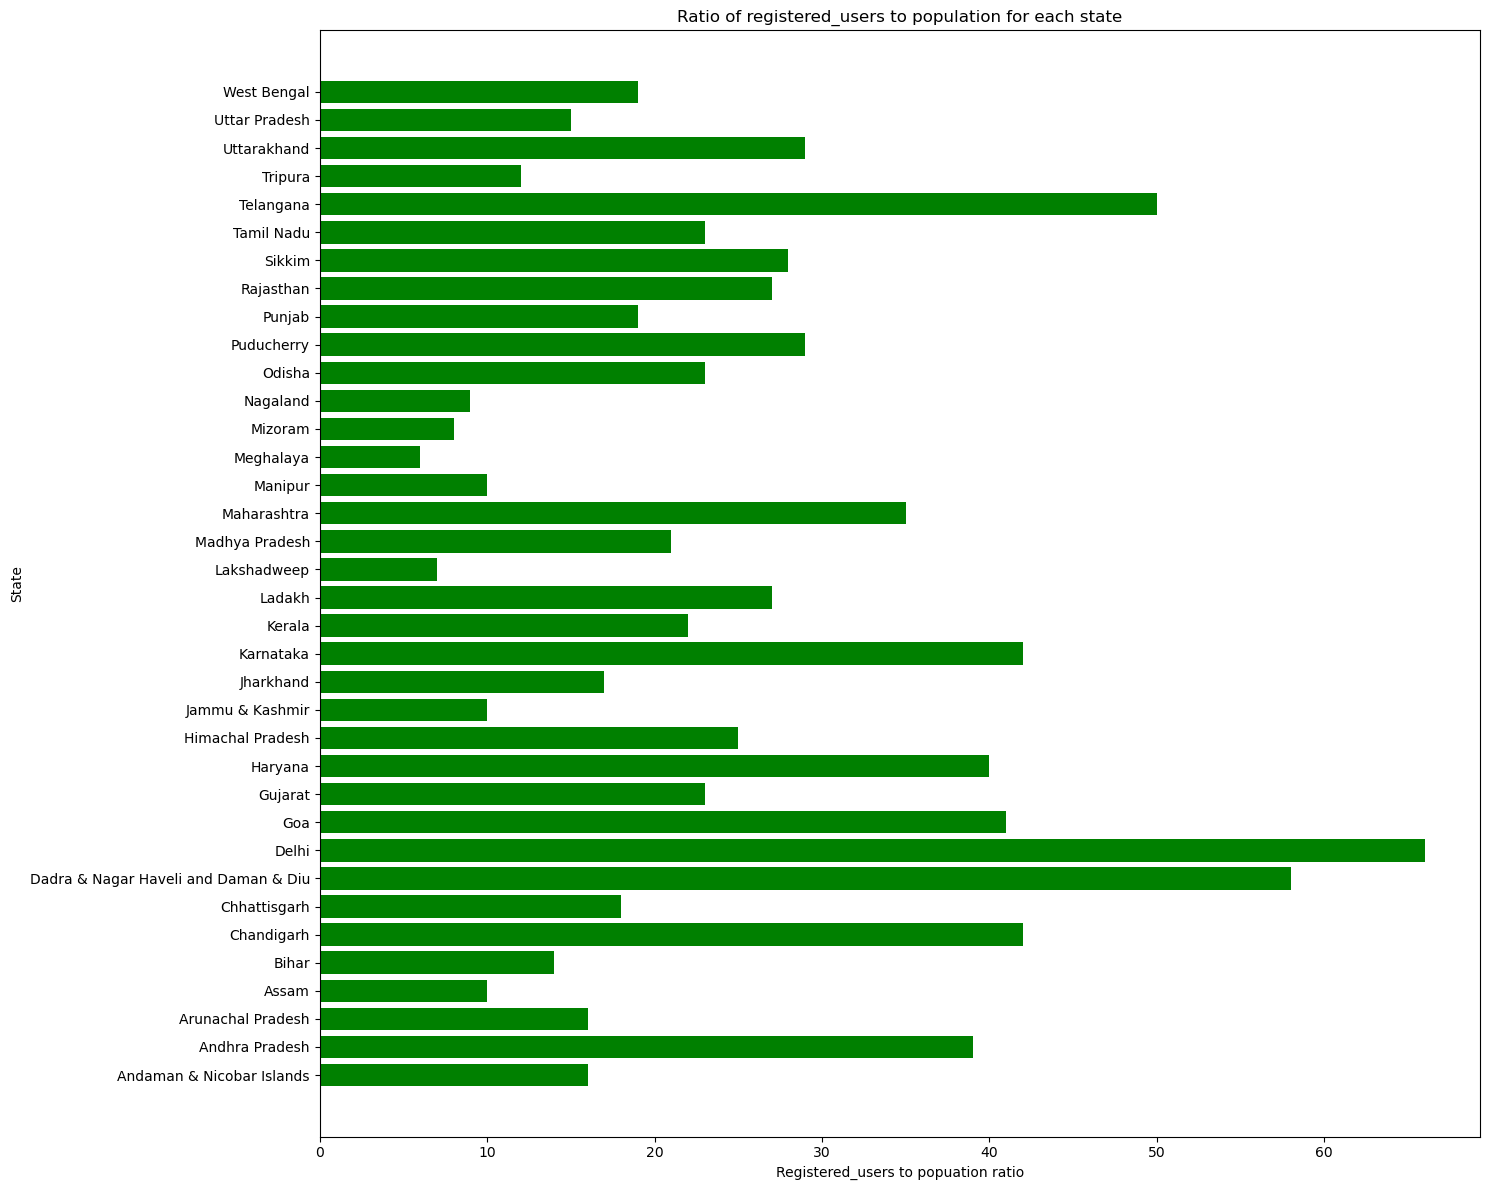

In [251]:
plt.figure(figsize=(15,12))
plt.barh(merged_data["State"], merged_data["Ratio"], color="green")
plt.xlabel("Registered_users to popuation ratio")
plt.ylabel("State")
plt.title("Ratio of registered_users to population for each state")
plt.tight_layout()
plt.savefig("Ratio of registered_users to population for each state.png",dpi=300,bbox_inches="tight")
plt.show()

In [267]:
#########################################

Task 11: Merge the d_txn_users with the district demographics and calculate the correlation btw population density and transaction volume.and create a scatter plot. 

In [260]:
# converting datatypes from object to int in d_txn_users
columns1=["Transactions","Amount (INR)","ATV (INR)","Registered Users","App Opens"]

In [261]:
d_txn_users[columns1]=d_txn_users[columns1].apply(lambda x:x.astype(str).str.replace(",",""))

In [262]:
d_txn_users[columns1]=d_txn_users[columns1].apply(lambda x:pd.to_numeric(x,errors="coerce"))

In [265]:
# getting latest data that is year 2021 and 2nd quarter

a=d_txn_users[(d_txn_users["Year"]==2021)&(d_txn_users["Quarter"]==2)].iloc[:,[0,5]]

In [266]:
a1=a.groupby("State")["Transactions"].sum().reset_index()

In [272]:
b=d_demo.loc[:,["State","Density"]]

In [274]:
b["Density"]=b["Density"].fillna(0)

In [277]:
b1=b.groupby("State")["Density"].mean().reset_index()

In [278]:
b1["Density"]=b1["Density"].astype("int64")

In [280]:
combined=pd.merge(a1,b1,on="State")

In [282]:
corr_txn_density=combined["Transactions"].corr(combined["Density"])

In [283]:
corr_txn_density

np.float64(0.025022404678360796)

Correlation analysis between average population density and transaction volume at the state level(most recent data) yielded a coefficient of 0.025, indicating no significant linear relationship.This implies that transaction volumes are influenced more by economic activity, digital adoption and infrastructure than by population density alone.

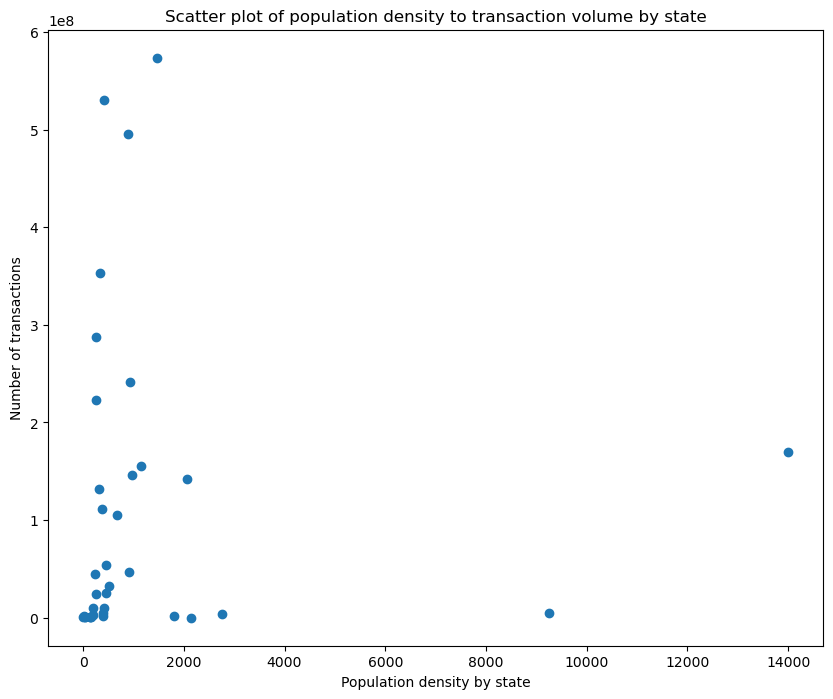

In [285]:
plt.figure(figsize=(10,8))
plt.scatter(combined["Density"],combined["Transactions"],marker="o")
plt.xlabel("Population density by state")
plt.ylabel("Number of transactions")
plt.title("Scatter plot of population density to transaction volume by state")
plt.savefig("scatter plot of population density to transaction volume for all states.png",dpi=300,bbox_inches="tight")
plt.show()

In [293]:
################################################

Task 12: Merge the relevant data sets to get the average transaction amount per user for each state.and getthe top 5 and bottom 5 states after sorting.

In [287]:
# getting the most recent data from s_txn_users and s_devicedata

recent_amts=s_txn_users[(s_txn_users["Year"]==2021)&(s_txn_users["Quarter"]==2)].iloc[:,[0,4]]

In [289]:
users=s_devicedata[(s_devicedata["Year"]==2021)&(s_devicedata["Quarter"]==2)].iloc[:,[0,4]]

In [290]:
users1=users.groupby("State")["Registered Users"].sum().reset_index()

In [292]:
res_df=pd.merge(recent_amts,users1,on="State")

In [294]:
res_df["Avg_amt_user"]=res_df["Amount (INR)"]/res_df["Registered Users"]

In [295]:
res_df["Avg_amt_user"]=res_df["Avg_amt_user"].astype("int64")

In [296]:
res_df1=res_df.sort_values(by="Avg_amt_user",ascending=False)

In [301]:
res_df1=res_df1.rename(columns={"Avg_amt_user":"Avg_amt_per_user"})

In [303]:
res_df1.to_excel("avg_Tamt-per_users.xlsx",index=False)

In [299]:
# Top 5 states with the highest average transaction amount per user are:

res_df1.head()

,State,Amount (INR),Registered Users,Avg_amt_user
31,Telangana,1027958332798,18306880,56151
1,Andhra Pradesh,850737499108,19620905,43358
15,Karnataka,837887151230,25751023,32538
28,Rajasthan,561702765169,18980985,29592
19,Madhya Pradesh,425500768036,15940935,26692


In [300]:
# states with the lowest average transaction amount per user are 

res_df1.tail()

,State,Amount (INR),Registered Users,Avg_amt_user
16,Kerala,74226806436,7416083,10008
12,Himachal Pradesh,16495634540,1743151,9463
7,Dadra & Nagar Haveli and Daman & Diu,3157668461,344994,9152
32,Tripura,3468154361,472153,7345
18,Lakshadweep,27383464,4896,5593


In [314]:
########################################

Task 13: Merge the state device data and state txn users and calculate the ratio of users from each device brand to the total registered users and create a barchart for each state.

In [304]:
aa1=s_txn_users[(s_txn_users["Year"]==2021)&(s_txn_users["Quarter"]==2)].iloc[:,[0,6]]

In [305]:
bb1=s_devicedata[(s_devicedata["Year"]==2021)&(s_devicedata["Quarter"]==2)].iloc[:,[0,3,4]]

In [307]:
data=pd.merge(bb1,aa1,on="State",suffixes=("_per_brand","_total"))

In [308]:
data["Ratio"]=data["Registered Users_per_brand"]*100/data["Registered Users_total"]

In [309]:
data["Ratio"]=data["Ratio"].astype("int64")

In [311]:
# barplot for Telangana state
plot_data=data[data["State"]=="Telangana"]

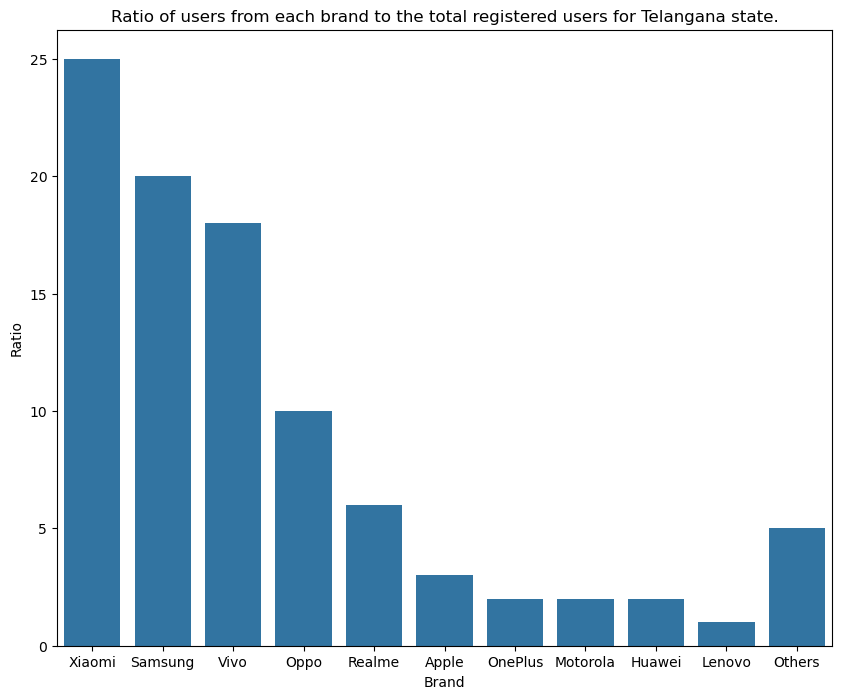

In [318]:
plt.figure(figsize=(10,8))
sns.barplot(data=plot_data,x="Brand",y="Ratio")
plt.xlabel("Brand")
plt.ylabel("Ratio")
plt.title("Ratio of users from each brand to the total registered users for Telangana state.")
plt.savefig("Barplot showing ratio of users from each brand to toal number of users(TS).png",dpi=300,bbox_inches="tight")
plt.show()

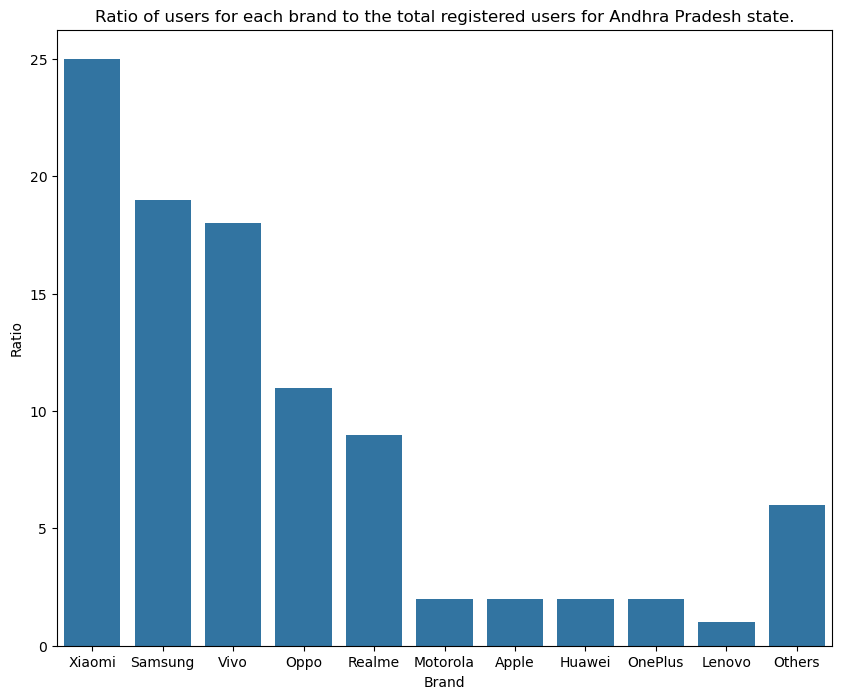

In [319]:
plt.figure(figsize=(10,8))
sns.barplot(data=data[data["State"]=="Andhra Pradesh"],x="Brand",y="Ratio")
plt.xlabel("Brand")
plt.ylabel("Ratio")
plt.title("Ratio of users for each brand to the total registered users for Andhra Pradesh state.")
plt.savefig("Barplot showing ratio of users from each brand to toal number of users(AP).png",dpi=300,bbox_inches="tight")
plt.show()

In [320]:
##################################

Task 14: Create a line plot for the total number of transactions and total transaction amount ove time for a selected state.

In [321]:
s_txn_users["Period"]=s_txn_users["Year"].astype(str)+"-Q"+s_txn_users["Quarter"].astype(str)

In [323]:
# for karnataka state
dataplot_KA=s_txn_users[s_txn_users["State"]=="Karnataka"]
# for Maharashtra
dataplot_MH=s_txn_users[s_txn_users["State"]=="Maharashtra"]

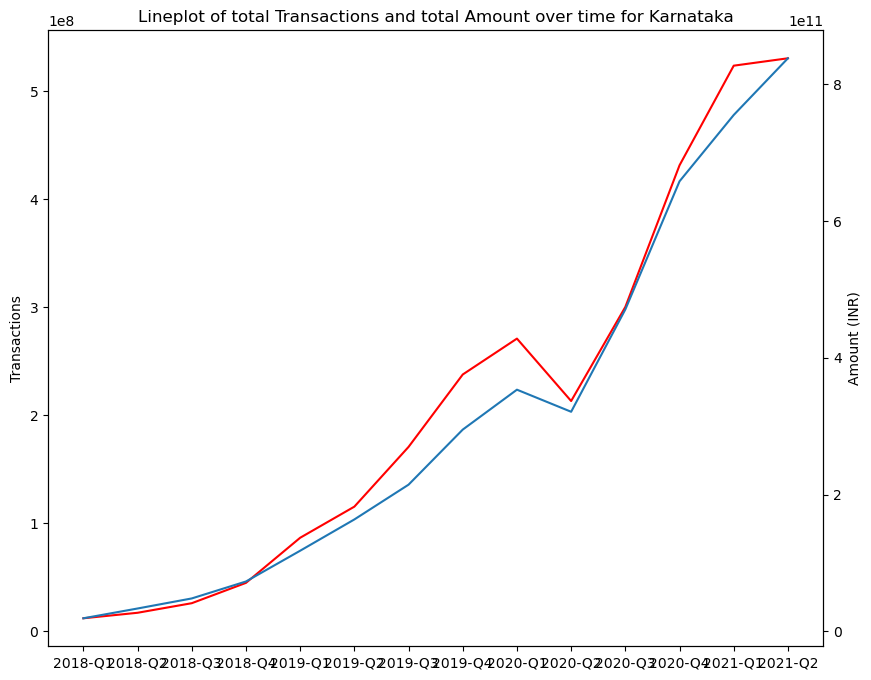

In [325]:
# line plot for Karnataka
fig,ax1=plt.subplots(figsize=(10,8))
ax1.plot(dataplot_KA["Period"],dataplot_KA["Transactions"],color="red",label="Transactions")
ax1.set_ylabel("Transactions")
ax2=ax1.twinx()
ax2.plot(dataplot_KA["Period"],dataplot_KA["Amount (INR)"],label="Amount (INR)")
ax2.set_ylabel("Amount (INR)")
plt.title("Lineplot of total Transactions and total Amount over time for Karnataka")
plt.savefig("Lineplot showing total number of transactions and total amount over time for Karnataka.png",dpi=300,bbox_inches="tight")
plt.show()

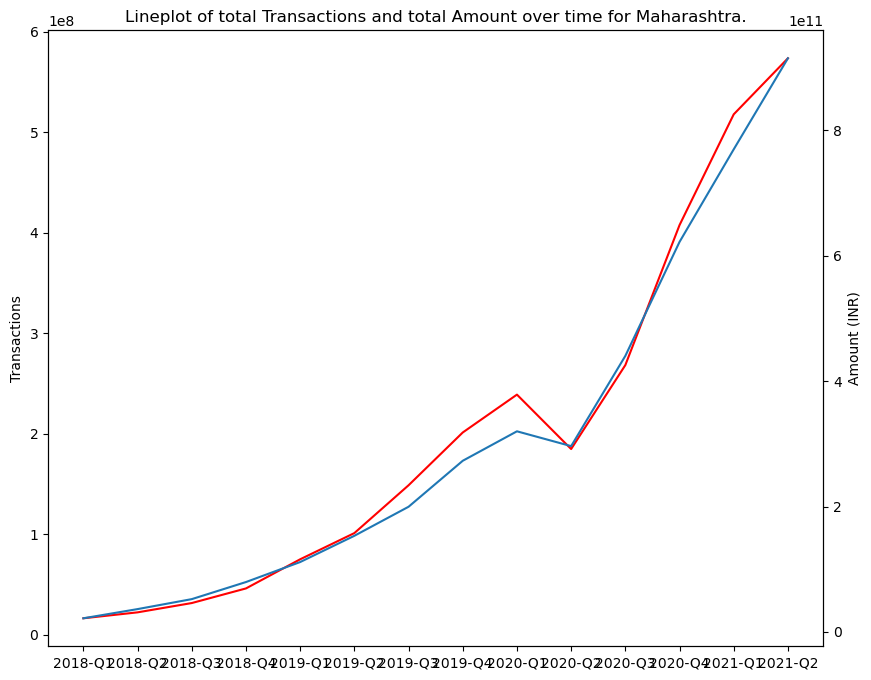

In [326]:
# line plot for Karnataka
fig,ax1=plt.subplots(figsize=(10,8))
ax1.plot(dataplot_MH["Period"],dataplot_MH["Transactions"],color="red",label="Transactions")
ax1.set_ylabel("Transactions")
ax2=ax1.twinx()
ax2.plot(dataplot_MH["Period"],dataplot_MH["Amount (INR)"],label="Amount (INR)")
ax2.set_ylabel("Amount (INR)")
plt.title("Lineplot of total Transactions and total Amount over time for Maharashtra.")
plt.savefig("Lineplot showing total number of transactions and total amount for Maharashtra.png",dpi=300,bbox_inches="tight")
plt.show()

In [360]:
##############################

Task 15: Create a pie chart showing the distribution of different transaction types for a specified quarter in a selected state.

In [327]:
# considering recent transaction data for telangana state for the recent quarter

dff=s_txnsplit[(s_txnsplit["State"]=="Telangana")&(s_txnsplit["Year"]==2021)&(s_txnsplit["Quarter"]==2)]

In [328]:
dff

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
2229,Telangana,2021,2,Peer-to-peer payments,230861833,872151973638,3778
2230,Telangana,2021,2,Merchant payments,205232899,123207789311,600
2231,Telangana,2021,2,Recharge & bill payments,58637866,31877277168,544
2232,Telangana,2021,2,Financial Services,278546,300569264,1079
2233,Telangana,2021,2,Others,856400,420723416,491


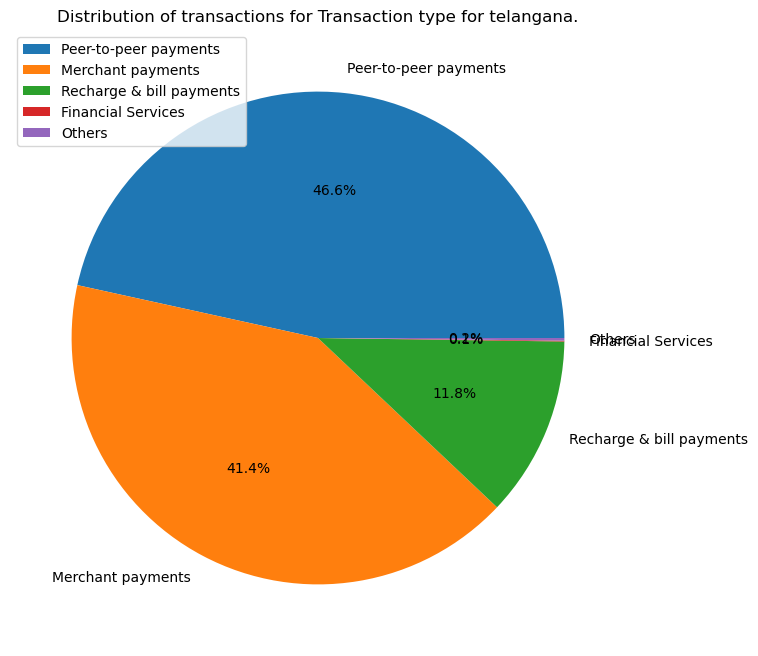

In [365]:
plt.figure(figsize=(8,8))
plt.pie(dff["Transactions"],labels=dff["Transaction Type"],autopct="%1.1f%%")
plt.title("Distribution of transactions for Transaction type for telangana.")
plt.legend()
plt.show()

In [329]:
#######################

Task 16: Create a barplot showing the population density for all districts in a particular state.

In [332]:
# for andhra pradesh
df_ap=d_demo[d_demo["State"]=="Andhra Pradesh"].iloc[:,[0,1,5]]

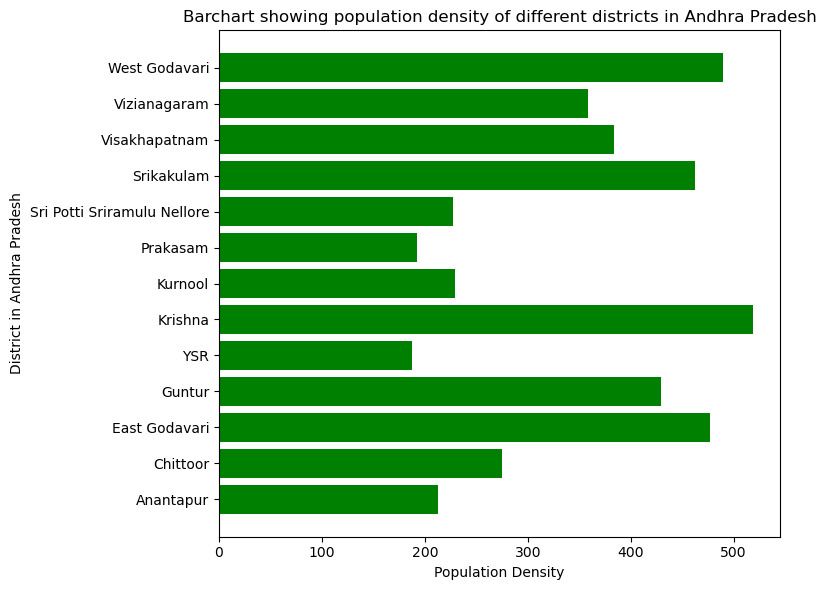

In [338]:
plt.figure(figsize=(8,6))
plt.barh(df_ap["District"], df_ap["Density"], color="green")
plt.xlabel("Population Density")
plt.ylabel("District in Andhra Pradesh")
plt.title("Barchart showing population density of different districts in Andhra Pradesh")
plt.tight_layout()
plt.savefig("Barchart showing population density of different districts in Andhra Pradesh.png",dpi=300,bbox_inches="tight")
plt.show()

In [339]:
# for Madhya Pradesh
df_mp=d_demo[d_demo["State"]=="Madhya Pradesh"].iloc[:,[0,1,5]]

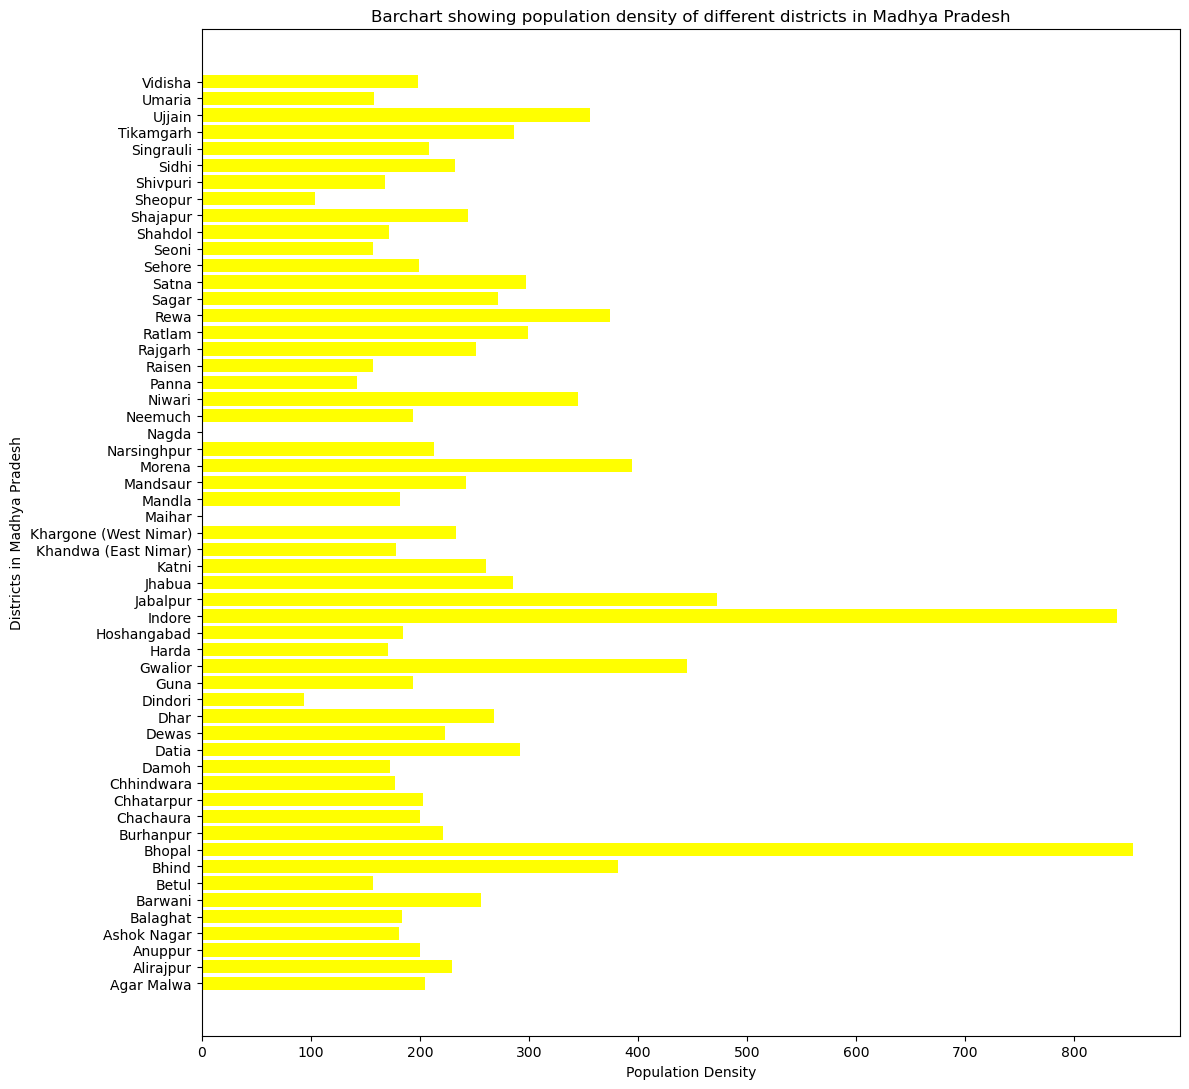

In [344]:
plt.figure(figsize=(12,11))
plt.barh(df_mp["District"], df_mp["Density"], color="yellow")
plt.xlabel("Population Density")
plt.ylabel("Districts in Madhya Pradesh")
plt.title("Barchart showing population density of different districts in Madhya Pradesh")
plt.tight_layout()
plt.savefig("Barchart showing population density of different districts in Madhya Pradesh.png",dpi=300,bbox_inches="tight")
plt.show()

In [353]:
###################################

Digital payments are more than numbers — they reflect how India’s people,from bustling metros to remote islands are embracing a new way of connecting,transacting and growing together.